In [1]:
%run nb1_setup.ipynb

# Notebook 3: Human vs LLM Comparison

Confusion matrices and per-model agreement statistics. LLM data filtered to repeat=0.

In [2]:
import os
for _r in range(4):
    os.makedirs(f"repeat_{_r}", exist_ok=True)

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

def _safe_mkdir(path):
    os.makedirs(path, exist_ok=True)
    return path

def _semantic_cm_colors(mat):
    """
    Column order: TP(0) FP(1) TN(2) FN(3).
    TP, TN (correct) → muted sage green; FP, FN (errors) → muted dusty rose.
    Intensity = count / column-max so each column self-normalises.
    Text always black.
    """
    import numpy as np
    rgba = np.ones((*mat.shape, 4))
    col_max = mat.max(axis=0).clip(min=1).astype(float)
    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            t = mat[i, j] / col_max[j]
            if j in (0, 2):  # TP, TN → green
                rgba[i, j] = (0.92 - t * 0.58, 0.97 - t * 0.40, 0.92 - t * 0.58, 1)
            else:             # FP, FN → rose
                rgba[i, j] = (0.99 - t * 0.09, 0.92 - t * 0.55, 0.92 - t * 0.55, 1)
    return rgba

def save_per_llm_outputs(analysis_results, output_dir, hash_column='reaction_hash',
                        llm_order=("Claude Opus 4.8", "Gemini 3.1 Pro", "GPT-5.5", "Llama 3.1 70B")):
    """
    Save all outputs per LLM:
      - per-LLM results_df subset
      - per-LLM stats row
      - per-LLM disagreement subset
      - per-LLM confusion matrices (category & sentiment)
      - per-LLM single-row TP/FP/TN/FN heatmap
    Also saves a combined TP/FP/TN/FN matrix across LLMs (multi-row) like the example image.
    """
    _safe_mkdir(output_dir)
    
    # Get mappings for aliases based on hash_column
    mappings = CategoryMappings.get_mappings(hash_column)
    aliases = mappings.get('aliases', {})
    
    results_df = analysis_results['results_df']
    matrix_df = analysis_results['matrix_df']      # TP/FP/TN/FN per LLM
    
    # Generate stats_df from results if not present
    stats_df = _generate_per_llm_stats(results_df) if 'stats_df' not in analysis_results else analysis_results['stats_df']

    # Combined TP/FP/TN/FN heatmap across all LLMs (multi-row)
    # Reorder according to llm_order if present in matrix_df
    matrix_df = matrix_df.set_index('llm_name')
    available_llms = [llm for llm in llm_order if llm in matrix_df.index]
    matrix_df = matrix_df.loc[available_llms].reset_index()
    llms = matrix_df['llm_name'].tolist()
    mat = matrix_df[['TP','FP','TN','FN']].values.astype(int)

    # Create combined agreement matrix — semantic colours: green=correct, red=error
    analysis_type = 'Reaction' if hash_column == 'reaction_hash' else 'Route'
    rgba = _semantic_cm_colors(mat)
    fig, ax = plt.subplots(figsize=(9, max(3, len(llms) * 1.4)))
    ax.imshow(rgba, aspect='auto')
    ax.set_xticks(range(4))
    ax.set_xticklabels(['TP', 'FP', 'TN', 'FN'], fontsize=15, fontweight='bold')
    ax.set_yticks(range(len(llms)))
    ax.set_yticklabels(llms, fontsize=12)
    # Column labels styled by semantics
    for j, (label, good) in enumerate(zip(['TP','FP','TN','FN'],[True,False,True,False])):
        ax.get_xticklabels()[j].set_color('#1a6e2e' if good else '#8b0000')
    ax.set_title(f'{analysis_type} — TP / FP / TN / FN', fontsize=13, fontweight='bold')
    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            val = int(mat[i, j])
            ax.text(j, i, f'{val}', ha='center', va='center',
                    color='black', fontsize=14, fontweight='bold')
    ax.spines[:].set_visible(False)
    ax.tick_params(length=0)
    for _i in range(mat.shape[0]):
        for _j in range(mat.shape[1]):
            ax.add_patch(plt.Rectangle((_j - 0.5, _i - 0.5), 1, 1,
                         fill=False, edgecolor='#bbbbbb', linewidth=0.7))
    ax.set_aspect('equal')
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, f'agreement_matrix_all_llms_{analysis_type}.png'), dpi=300, bbox_inches='tight')
    plt.close()

    # Per-LLM outputs
    for llm_name in llms:
        llm_dir = _safe_mkdir(os.path.join(output_dir, f'llm_{llm_name}'))

        # Per-LLM comparisons CSV
        sub = results_df[results_df['llm_name'] == llm_name].copy()
        sub.to_csv(os.path.join(llm_dir, f'human_vs_{llm_name}_comparisons_{analysis_type}.csv'), index=False)

        # Per-LLM TP/FP/TN/FN row and single-row heatmap — semantic colours
        row = matrix_df[matrix_df['llm_name'] == llm_name][['TP','FP','TN','FN']].values.astype(int).flatten()
        rgba_row = _semantic_cm_colors(row.reshape(1, -1))
        fig, ax = plt.subplots(figsize=(7, 1.8))
        ax.imshow(rgba_row, aspect='auto')
        ax.set_xticks(range(4))
        ax.set_xticklabels(['TP', 'FP', 'TN', 'FN'], fontsize=12, fontweight='bold')
        for j, good in enumerate([True, False, True, False]):
            ax.get_xticklabels()[j].set_color('#1a6e2e' if good else '#8b0000')
        ax.set_yticks([0])
        ax.set_yticklabels([llm_name], fontsize=11)
        ax.set_title(f'{llm_name}', fontsize=11, fontweight='bold')
        for j in range(4):
            ax.text(j, 0, f'{int(row[j])}', ha='center', va='center',
                    color='black', fontsize=12, fontweight='bold')
        ax.spines[:].set_visible(False)
        ax.tick_params(length=0)
        for _j in range(4):
            ax.add_patch(plt.Rectangle((_j - 0.5, -0.5), 1, 1,
                         fill=False, edgecolor='#bbbbbb', linewidth=0.7))
        ax.set_aspect('equal')
        plt.tight_layout()
        plt.savefig(os.path.join(llm_dir, f'agreement_matrix_{llm_name}_{analysis_type}.png'), dpi=300, bbox_inches='tight')
        plt.close()

        # Per-LLM confusion matrices for categories and sentiment
        # Build confusion matrices from per-LLM subset
        hc = sub['human_dominant_category'].tolist()
        lc = sub['llm_dominant_category'].tolist()

        if len(hc) > 0 and len(lc) > 0:
            # Get all categories present in the data
            all_cats_in_data = set(hc + lc)
            
            # Order categories by hierarchy (most positive to most negative)
            mappings = CategoryMappings.get_mappings(hash_column)
            hierarchy = mappings['hierarchy']
            
            # Separate into categories with hierarchy values and those without
            categorized = [cat for cat in all_cats_in_data if cat in hierarchy]
            uncategorized = [cat for cat in all_cats_in_data if cat not in hierarchy]
            
            # Sort categorized by hierarchy value (descending - most positive first)
            categorized.sort(key=lambda x: hierarchy[x], reverse=True)
            
            # Combine: hierarchy-ordered first, then alphabetically sorted uncategorized
            all_cats = categorized + sorted(uncategorized)
            
            cm_cat = confusion_matrix(hc, lc, labels=all_cats)

            hs = sub['human_sentiment'].tolist()
            ls = sub['llm_sentiment'].tolist()
            sent_labels = ['Positive', 'Negative']
            cm_sent = confusion_matrix(hs, ls, labels=sent_labels)

            # Category confusion heatmap
            disp_cats = [c for c in all_cats]
            alias_labels = [aliases.get(lbl, lbl) for lbl in disp_cats]
            plt.figure(figsize=(10, 8))
            im = plt.imshow(cm_cat, cmap='Blues', aspect='auto')
            plt.title(f'{llm_name}', fontsize=16, fontweight='bold')
            plt.xlabel('LLM Predicted', fontsize=14)
            plt.ylabel('Human Ground Truth', fontsize=14)
            plt.xticks(range(len(alias_labels)), alias_labels, rotation=45, ha='right', fontsize=12)
            plt.yticks(range(len(alias_labels)), alias_labels, fontsize=12)
            cbar = plt.colorbar(im, fraction=0.046, pad=0.04)
            cbar.set_label('Count', fontsize=12, rotation=90)
            
            # Annotate cells
            max_val = cm_cat.max() if cm_cat.size > 0 else 1
            for i in range(cm_cat.shape[0]):
                for j in range(cm_cat.shape[1]):
                    val = int(cm_cat[i, j])
                    plt.text(j, i, str(val),
                            ha='center', va='center',
                            color='white' if val > max_val/2 else 'black', 
                            fontsize=12, fontweight='bold')
            plt.tight_layout()
            plt.savefig(os.path.join(llm_dir, f'confusion_categories_{llm_name}_{analysis_type}.png'), dpi=300, bbox_inches='tight')
            plt.close()

            # Sentiment confusion heatmap
            plt.figure(figsize=(6, 5))
            im = plt.imshow(cm_sent, cmap='RdYlBu', aspect='auto')
            plt.title(f'Sentiment Confusion – {llm_name}', fontsize=14, fontweight='bold')
            plt.xlabel('LLM Predicted', fontsize=14)
            plt.ylabel('Human Ground Truth', fontsize=14)
            plt.xticks(range(len(sent_labels)), sent_labels, fontsize=16)
            plt.yticks(range(len(sent_labels)), sent_labels, fontsize=16)
            cbar = plt.colorbar(im, fraction=0.046, pad=0.04)
            cbar.set_label('Count', fontsize=14, rotation=90)
            
            max_val = cm_sent.max() if cm_sent.size > 0 else 1
            for i in range(cm_sent.shape[0]):
                for j in range(cm_sent.shape[1]):
                    val = int(cm_sent[i, j])
                    plt.text(j, i, str(val),
                            ha='center', va='center',
                            color='white' if val > max_val/2 else 'black', 
                            fontsize=14, fontweight='bold')
            plt.tight_layout()
            plt.savefig(os.path.join(llm_dir, f'confusion_sentiment_{llm_name}_{analysis_type}.png'), dpi=300, bbox_inches='tight')
            plt.close()

        # Per-LLM stats row
        if stats_df is not None and not stats_df.empty:
            srow = stats_df[stats_df['llm_name'] == llm_name]
            if not srow.empty:
                srow.to_csv(os.path.join(llm_dir, f'stats_{llm_name}_{analysis_type}.csv'), index=False)

def _generate_per_llm_stats(results_df):
    """Generate per-LLM statistics from results_df"""
    stats_rows = []
    
    for llm_name in results_df['llm_name'].unique():
        sub = results_df[results_df['llm_name'] == llm_name]
        total = len(sub)
        
        if total > 0:
            cat_agreement = int(sub['category_agreement'].sum())
            sent_agreement = int(sub['sentiment_agreement'].sum())
            
            # Calculate percentages
            cat_pct = round((cat_agreement / total) * 100, 1)
            sent_pct = round((sent_agreement / total) * 100, 1)
            
            # Score differences
            score_diffs = sub['score_difference']
            mean_score_diff = round(score_diffs.mean(), 2)
            std_score_diff = round(score_diffs.std(), 2)
            max_score_diff = int(score_diffs.max())
            
            # Cohen's kappa for this LLM
            hc = sub['human_dominant_category'].tolist()
            lc = sub['llm_dominant_category'].tolist()
            all_cats = sorted(set(hc + lc))
            
            if len(all_cats) > 1:
                mapping = {c: i for i, c in enumerate(all_cats)}
                human_numeric = [mapping[c] for c in hc]
                llm_numeric = [mapping[c] for c in lc]
                kappa = round(cohen_kappa_score(human_numeric, llm_numeric), 3)
            else:
                kappa = 1.0
            
            stats_rows.append({
                'llm_name': llm_name,
                'total_comparisons': total,
                'category_agreement_count': cat_agreement,
                'category_agreement_percentage': cat_pct,
                'sentiment_agreement_count': sent_agreement,
                'sentiment_agreement_percentage': sent_pct,
                'cohens_kappa': kappa,
                'mean_score_difference': mean_score_diff,
                'std_score_difference': std_score_diff,
                'max_score_difference': max_score_diff
            })
    
    return pd.DataFrame(stats_rows)


def run_human_vs_llm_analysis_per_model(feedback_csv, hash_column='reaction_hash',
                                       output_dir='repeat_0/human_vs_llm_per_model',
                                       category_column='local_feedback',
                                       expert_column='source_file',
                                       text_column='local_feedback_text',
                                       confidence_column='confidence',
                                       llm_order=("Claude Opus 4.8", "Gemini 3.1 Pro", "GPT-5.5", "Llama 3.1 70B"),
                                       llm_repeat=0):
    """
    Wrapper: run the majority comparison, then save per-LLM outputs and combined matrix.
    """
    os.makedirs(output_dir, exist_ok=True)
    feedback_df = pd.read_csv(feedback_csv)

    analysis_type = 'Reactions' if hash_column == 'reaction_hash' else 'Routes'
    print(f"Starting Human vs LLM Majority Agreement Analysis (per LLM outputs) - {analysis_type}...")
    print("=" * 70)
    
    # Run analysis with specified parameters
    analysis = analyze_human_vs_llm_agreement(
        feedback_df,
        hash_column=hash_column,
        category_column=category_column,
        expert_column=expert_column,
        text_column=text_column,
        confidence_column=confidence_column,
        llm_repeat=llm_repeat
    )
    
    if not analysis:
        print("Analysis failed. Please check your data.")
        return

    # Generate per-LLM stats if not present
    if 'stats_df' not in analysis:
        analysis['stats_df'] = _generate_per_llm_stats(analysis['results_df'])

    # Save global results for reference
    analysis['results_df'].to_csv(os.path.join(output_dir, 'human_vs_llm_majority_all.csv'), index=False)
    analysis['matrix_df'].to_csv(os.path.join(output_dir, 'human_vs_llm_majority_matrix_all.csv'), index=False)
    analysis['stats_df'].to_csv(os.path.join(output_dir, 'human_vs_llm_majority_stats_all.csv'), index=False)


    # Save per-LLM outputs and combined matrix heatmap
    save_per_llm_outputs(analysis, output_dir, hash_column=hash_column, llm_order=llm_order)

    print(f"\nPer-LLM outputs saved under {output_dir}/")
    return analysis

In [16]:
for repeat in range(4):
    os.makedirs(f"repeat_{repeat}", exist_ok=True)
    print(f"\n=== Reactions analysis repeat={repeat} ===")
    run_human_vs_llm_analysis_per_model(
        'expert_feedback_combined_new_llms.csv',
        hash_column='reaction_hash',
        output_dir=f'repeat_{repeat}/reactions_analysis',
        llm_repeat=repeat,
    )
    print(f"\n=== Routes analysis repeat={repeat} ===")
    run_human_vs_llm_analysis_per_model(
        'expert_feedback_combined_new_llms.csv',
        hash_column='root_molecule_hash',
        category_column='general_feedback',
        expert_column='source_file',
        text_column='general_feedback_text',
        output_dir=f'repeat_{repeat}/routes_analysis',
        llm_repeat=repeat,
    )



=== Reactions analysis repeat=0 ===
Starting Human vs LLM Majority Agreement Analysis (per LLM outputs) - Reactions...
Human experts: 17
LLM experts: 4
Total human feedback entries: 991
Total LLM feedback entries: 3208
Reactions evaluated by humans only: 0
Reactions evaluated by LLMs only: 0
Reactions evaluated by both: 204

Per-LLM outputs saved under repeat_0/reactions_analysis/

=== Routes analysis repeat=0 ===
Starting Human vs LLM Majority Agreement Analysis (per LLM outputs) - Routes...
Human experts: 16
LLM experts: 4
Total human feedback entries: 200
Total LLM feedback entries: 3989
Reactions evaluated by humans only: 0
Reactions evaluated by LLMs only: 0
Reactions evaluated by both: 50

Per-LLM outputs saved under repeat_0/routes_analysis/

=== Reactions analysis repeat=1 ===
Starting Human vs LLM Majority Agreement Analysis (per LLM outputs) - Reactions...
Human experts: 17
LLM experts: 4
Total human feedback entries: 991
Total LLM feedback entries: 3205
Reactions evaluated 

## Averaged Confusion Matrix — Option A: Mean Raw Counts (± SD)

Each cell shows the mean count across 4 repeats with standard deviation.
The colour encodes the mean; the ±SD in the annotation reflects run-to-run stability.


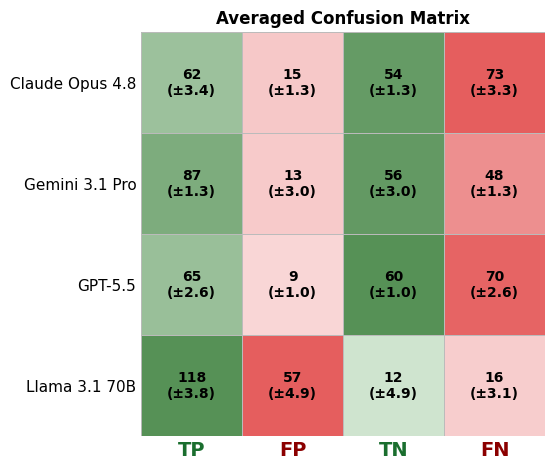

Saved results/averaged_cm_raw_counts_reactions.png


In [3]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix as sk_cm

CSV = "expert_feedback_combined_new_llms.csv"
LLM_IDENTIFIERS = ["Claude Opus 4.8", "Gemini 3.1 Pro", "GPT-5.5", "Llama 3.1 70B"]
os.makedirs("results", exist_ok=True)

df = pd.read_csv(CSV)
human_mask = ~df["source_file"].isin(LLM_IDENTIFIERS)
human_df   = df[human_mask & df["local_feedback"].notna() & df["reaction_hash"].notna()].copy()
llm_df     = df[~human_mask & (df["feedback_type"] == "reaction")].copy()

# Build human ground truth (fixed, same as nb2)
human_labels = {}
for rxn_hash, grp in human_df.groupby("reaction_hash"):
    res = GroupConsensusAnalyzer("reaction_hash").get_group_consensus(
        grp, "source_file", "local_feedback", "local_feedback_text"
    )
    sent = res["dominant_sentiment"]
    if sent in ("Positive", "Negative"):
        human_labels[rxn_hash] = 1 if sent == "Positive" else 0

repeats = sorted(llm_df["repeat"].dropna().unique().astype(int))
ga = GroupConsensusAnalyzer("reaction_hash")

# Collect TP FP TN FN per model per repeat
counts_by_model = {llm: [] for llm in LLM_IDENTIFIERS}  # list of [TP, FP, TN, FN] per repeat
for llm in LLM_IDENTIFIERS:
    for r in repeats:
        sub = llm_df[(llm_df["source_file"] == llm) & (llm_df["repeat"] == r)]
        y_true, y_pred = [], []
        for rxn_hash, grp in sub.groupby("reaction_hash"):
            if rxn_hash not in human_labels:
                continue
            res = ga.get_group_consensus(grp, "source_file", "local_feedback", "local_feedback_text")
            sent = res["dominant_sentiment"]
            if sent not in ("Positive", "Negative"):
                continue
            y_true.append(human_labels[rxn_hash])
            y_pred.append(1 if sent == "Positive" else 0)
        if len(set(y_true)) < 2 or len(set(y_pred)) < 2:
            counts_by_model[llm].append([np.nan]*4)
            continue
        tn, fp, fn, tp = sk_cm(y_true, y_pred).ravel()
        counts_by_model[llm].append([tp, fp, tn, fn])

# Plot: 4-row multi-row heatmap of means, annotated with mean±SD
col_labels = ["TP", "FP", "TN", "FN"]
n_llms = len(LLM_IDENTIFIERS)
mat_mean = np.zeros((n_llms, 4))
mat_sd   = np.zeros((n_llms, 4))
for i, llm in enumerate(LLM_IDENTIFIERS):
    arr = np.array([r for r in counts_by_model[llm] if not np.isnan(r[0])])
    mat_mean[i] = arr.mean(axis=0)
    mat_sd[i]   = arr.std(axis=0, ddof=1) if len(arr) > 1 else np.zeros(4)

# Semantic colours: TP(0) FP(1) TN(2) FN(3) — same helper as per-repeat matrices
rgba = _semantic_cm_colors(mat_mean.astype(int))

fig, ax = plt.subplots(figsize=(7, max(3, n_llms * 1.2)))
ax.imshow(rgba, aspect="equal")
ax.set_xticks(range(4))
ax.set_xticklabels(col_labels, fontsize=14, fontweight="bold")
for j, good in enumerate([True, False, True, False]):
    ax.get_xticklabels()[j].set_color("#1a6e2e" if good else "#8b0000")
ax.set_yticks(range(n_llms))
ax.set_yticklabels(LLM_IDENTIFIERS, fontsize=11)
ax.set_title("Averaged Confusion Matrix", fontsize=12, fontweight="bold")
for i in range(n_llms):
    for j in range(4):
        m, s = mat_mean[i, j], mat_sd[i, j]
        ax.text(j, i, f"{m:.0f}\n(±{s:.1f})",
                ha="center", va="center", color="black", fontsize=10, fontweight="bold")
for i in range(n_llms):
    for j in range(4):
        ax.add_patch(plt.Rectangle((j - 0.5, i - 0.5), 1, 1,
                     fill=False, edgecolor="#bbbbbb", linewidth=0.7))
ax.spines[:].set_visible(False)
ax.tick_params(length=0)
plt.tight_layout()
plt.savefig("results/averaged_cm_raw_counts_reactions.png", dpi=200, bbox_inches="tight")
plt.show()
print("Saved results/averaged_cm_raw_counts_reactions.png")


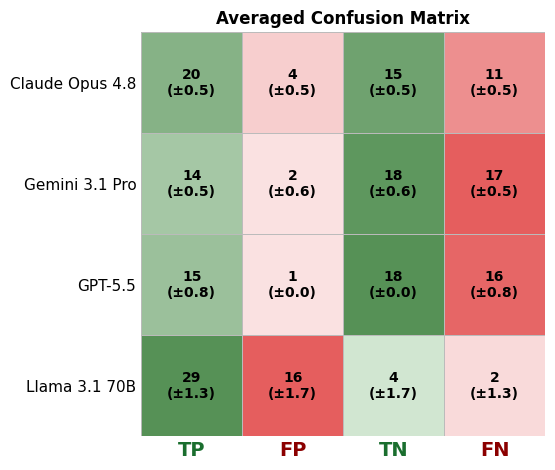

Saved results/averaged_cm_raw_counts_routes.png


In [4]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix as sk_cm

CSV = "expert_feedback_combined_new_llms.csv"
LLM_IDENTIFIERS = ["Claude Opus 4.8", "Gemini 3.1 Pro", "GPT-5.5", "Llama 3.1 70B"]
os.makedirs("results", exist_ok=True)

df = pd.read_csv(CSV)
human_mask = ~df["source_file"].isin(LLM_IDENTIFIERS)
human_df   = df[human_mask & df["general_feedback"].notna() & df["root_molecule_hash"].notna()].copy()
llm_df     = df[~human_mask & (df["feedback_type"] == "general")].copy()

# Build human ground truth (fixed, same as nb2)
human_labels = {}
for rxn_hash, grp in human_df.groupby("root_molecule_hash"):
    res = GroupConsensusAnalyzer("root_molecule_hash").get_group_consensus(
        grp, "source_file", "general_feedback", "general_feedback_text"
    )
    sent = res["dominant_sentiment"]
    if sent in ("Positive", "Negative"):
        human_labels[rxn_hash] = 1 if sent == "Positive" else 0

repeats = sorted(llm_df["repeat"].dropna().unique().astype(int))
ga = GroupConsensusAnalyzer("root_molecule_hash")

# Collect TP FP TN FN per model per repeat
counts_by_model = {llm: [] for llm in LLM_IDENTIFIERS}  # list of [TP, FP, TN, FN] per repeat
for llm in LLM_IDENTIFIERS:
    for r in repeats:
        sub = llm_df[(llm_df["source_file"] == llm) & (llm_df["repeat"] == r)]
        y_true, y_pred = [], []
        for rxn_hash, grp in sub.groupby("root_molecule_hash"):
            if rxn_hash not in human_labels:
                continue
            res = ga.get_group_consensus(grp, "source_file", "general_feedback", "general_feedback_text")
            sent = res["dominant_sentiment"]
            if sent not in ("Positive", "Negative"):
                continue
            y_true.append(human_labels[rxn_hash])
            y_pred.append(1 if sent == "Positive" else 0)
        if len(set(y_true)) < 2 or len(set(y_pred)) < 2:
            counts_by_model[llm].append([np.nan]*4)
            continue
        tn, fp, fn, tp = sk_cm(y_true, y_pred).ravel()
        counts_by_model[llm].append([tp, fp, tn, fn])

# Plot: 4-row multi-row heatmap of means, annotated with mean±SD
col_labels = ["TP", "FP", "TN", "FN"]
n_llms = len(LLM_IDENTIFIERS)
mat_mean = np.zeros((n_llms, 4))
mat_sd   = np.zeros((n_llms, 4))
for i, llm in enumerate(LLM_IDENTIFIERS):
    arr = np.array([r for r in counts_by_model[llm] if not np.isnan(r[0])])
    mat_mean[i] = arr.mean(axis=0)
    mat_sd[i]   = arr.std(axis=0, ddof=1) if len(arr) > 1 else np.zeros(4)

# Semantic colours: TP(0) FP(1) TN(2) FN(3) — same helper as per-repeat matrices
rgba = _semantic_cm_colors(mat_mean.astype(int))

fig, ax = plt.subplots(figsize=(7, max(3, n_llms * 1.2)))
ax.imshow(rgba, aspect="equal")
ax.set_xticks(range(4))
ax.set_xticklabels(col_labels, fontsize=14, fontweight="bold")
for j, good in enumerate([True, False, True, False]):
    ax.get_xticklabels()[j].set_color("#1a6e2e" if good else "#8b0000")
ax.set_yticks(range(n_llms))
ax.set_yticklabels(LLM_IDENTIFIERS, fontsize=11)
ax.set_title("Averaged Confusion Matrix", fontsize=12, fontweight="bold")
for i in range(n_llms):
    for j in range(4):
        m, s = mat_mean[i, j], mat_sd[i, j]
        ax.text(j, i, f"{m:.0f}\n(±{s:.1f})",
                ha="center", va="center", color="black", fontsize=10, fontweight="bold")
for i in range(n_llms):
    for j in range(4):
        ax.add_patch(plt.Rectangle((j - 0.5, i - 0.5), 1, 1,
                     fill=False, edgecolor="#bbbbbb", linewidth=0.7))
ax.spines[:].set_visible(False)
ax.tick_params(length=0)
plt.tight_layout()
plt.savefig("results/averaged_cm_raw_counts_routes.png", dpi=200, bbox_inches="tight")
plt.show()
print("Saved results/averaged_cm_raw_counts_routes.png")


## Averaged Confusion Matrix — Option B: Row-Normalised Rates (%, ± SD)

Each cell shows the mean rate across 4 repeats.
- **TP / FN** are normalised by total actual Positives → read as Recall (row 1) and Miss Rate (row 2)
- **TN / FP** are normalised by total actual Negatives → read as Specificity (row 3) and Fall-out (row 4)

This makes models directly comparable regardless of class balance.


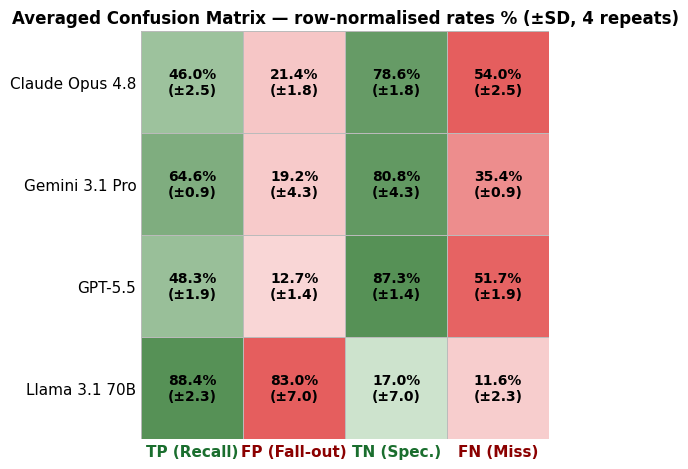

Saved results/averaged_cm_rates.png


In [20]:
# Collect row-normalised rates per model per repeat
# TP/FN normalised by P (actual positives), TN/FP normalised by N (actual negatives)
rates_by_model = {llm: [] for llm in LLM_IDENTIFIERS}
for llm in LLM_IDENTIFIERS:
    for r in repeats:
        sub = llm_df[(llm_df["source_file"] == llm) & (llm_df["repeat"] == r)]
        y_true, y_pred = [], []
        for rxn_hash, grp in sub.groupby("reaction_hash"):
            if rxn_hash not in human_labels:
                continue
            res = ga.get_group_consensus(grp, "source_file", "local_feedback", "local_feedback_text")
            sent = res["dominant_sentiment"]
            if sent not in ("Positive", "Negative"):
                continue
            y_true.append(human_labels[rxn_hash])
            y_pred.append(1 if sent == "Positive" else 0)
        if len(set(y_true)) < 2 or len(set(y_pred)) < 2:
            rates_by_model[llm].append([np.nan]*4)
            continue
        tn, fp, fn, tp = sk_cm(y_true, y_pred).ravel()
        P = tp + fn   # actual positives
        N = tn + fp   # actual negatives
        rates_by_model[llm].append([
            tp / P * 100,   # TP rate = Recall
            fp / N * 100,   # FP rate = Fall-out
            tn / N * 100,   # TN rate = Specificity
            fn / P * 100,   # FN rate = Miss rate
        ])

rate_mean = np.zeros((n_llms, 4))
rate_sd   = np.zeros((n_llms, 4))
for i, llm in enumerate(LLM_IDENTIFIERS):
    arr = np.array([r for r in rates_by_model[llm] if not np.isnan(r[0])])
    rate_mean[i] = arr.mean(axis=0)
    rate_sd[i]   = arr.std(axis=0, ddof=1) if len(arr) > 1 else np.zeros(4)

# Use rate_mean to drive colours (same semantic scheme, rescaled to 0–100)
rgba_rate = _semantic_cm_colors((rate_mean).astype(int).clip(0, 100))

fig, ax = plt.subplots(figsize=(7, max(3, n_llms * 1.2)))
ax.imshow(rgba_rate, aspect="equal")
ax.set_xticks(range(4))
col_labels_rate = ["TP (Recall)", "FP (Fall-out)", "TN (Spec.)", "FN (Miss)"]
ax.set_xticklabels(col_labels_rate, fontsize=11, fontweight="bold")
for j, good in enumerate([True, False, True, False]):
    ax.get_xticklabels()[j].set_color("#1a6e2e" if good else "#8b0000")
ax.set_yticks(range(n_llms))
ax.set_yticklabels(LLM_IDENTIFIERS, fontsize=11)
ax.set_title("Averaged Confusion Matrix — row-normalised rates % (±SD, 4 repeats)", fontsize=12, fontweight="bold")
for i in range(n_llms):
    for j in range(4):
        m, s = rate_mean[i, j], rate_sd[i, j]
        ax.text(j, i, f"{m:.1f}%\n(±{s:.1f})",
                ha="center", va="center", color="black", fontsize=10, fontweight="bold")
for i in range(n_llms):
    for j in range(4):
        ax.add_patch(plt.Rectangle((j - 0.5, i - 0.5), 1, 1,
                     fill=False, edgecolor="#bbbbbb", linewidth=0.7))
ax.spines[:].set_visible(False)
ax.tick_params(length=0)
plt.tight_layout()
plt.savefig("results/averaged_cm_rates.png", dpi=200, bbox_inches="tight")
plt.show()
print("Saved results/averaged_cm_rates.png")


## Averaged Category Confusion Matrix — Mean Counts (± SD)

Full category-level confusion matrix averaged across 4 repeats, for both reactions and routes.
One plot per LLM × analysis type saved to `results/`.
Human rows = ground truth categories; LLM columns = predicted categories.
Diagonal = agreement; off-diagonal = which categories the LLM confuses.


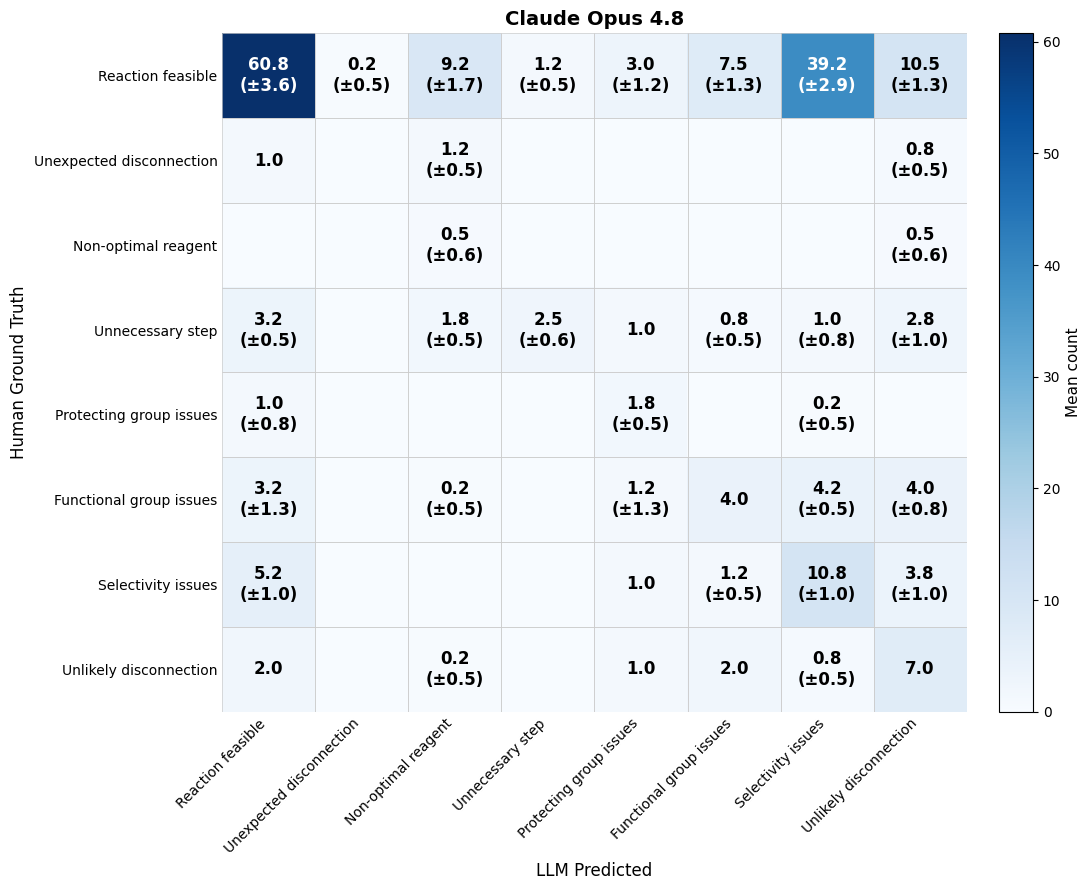

Saved results/averaged_cm_categories_Claude_Opus_4.8_Reaction.png


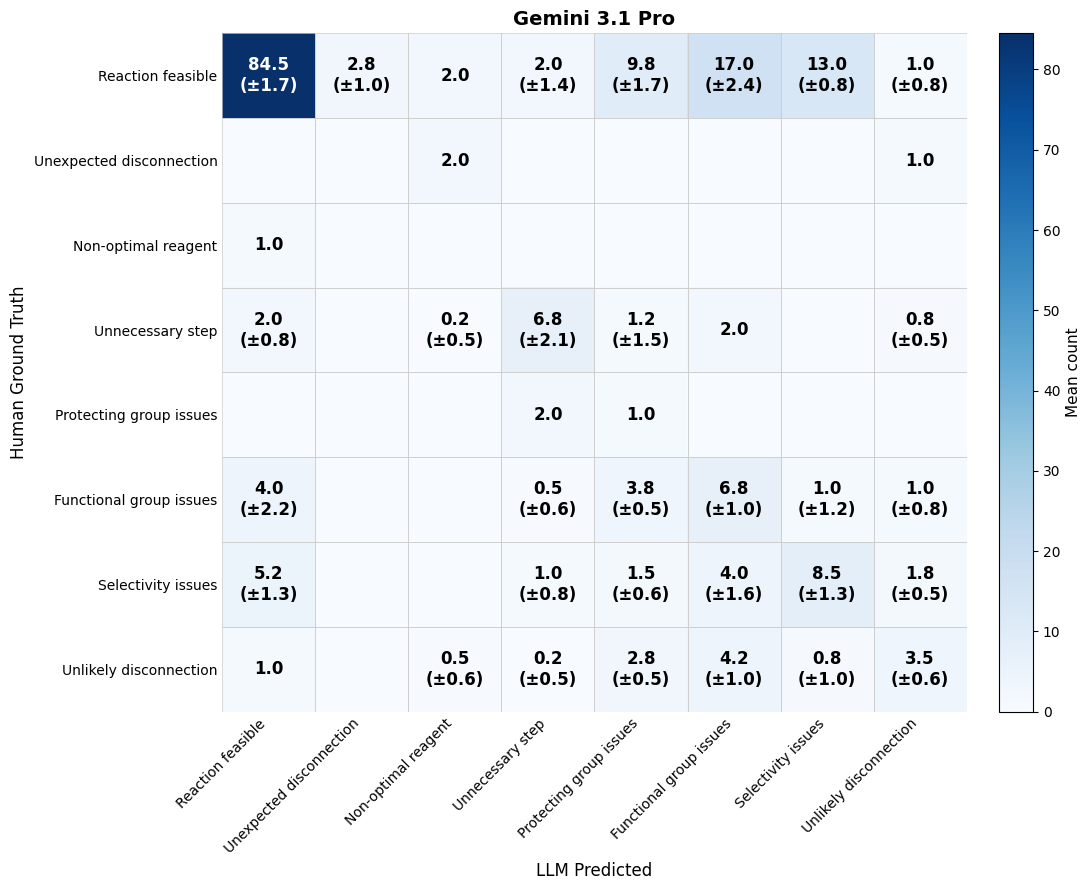

Saved results/averaged_cm_categories_Gemini_3.1_Pro_Reaction.png


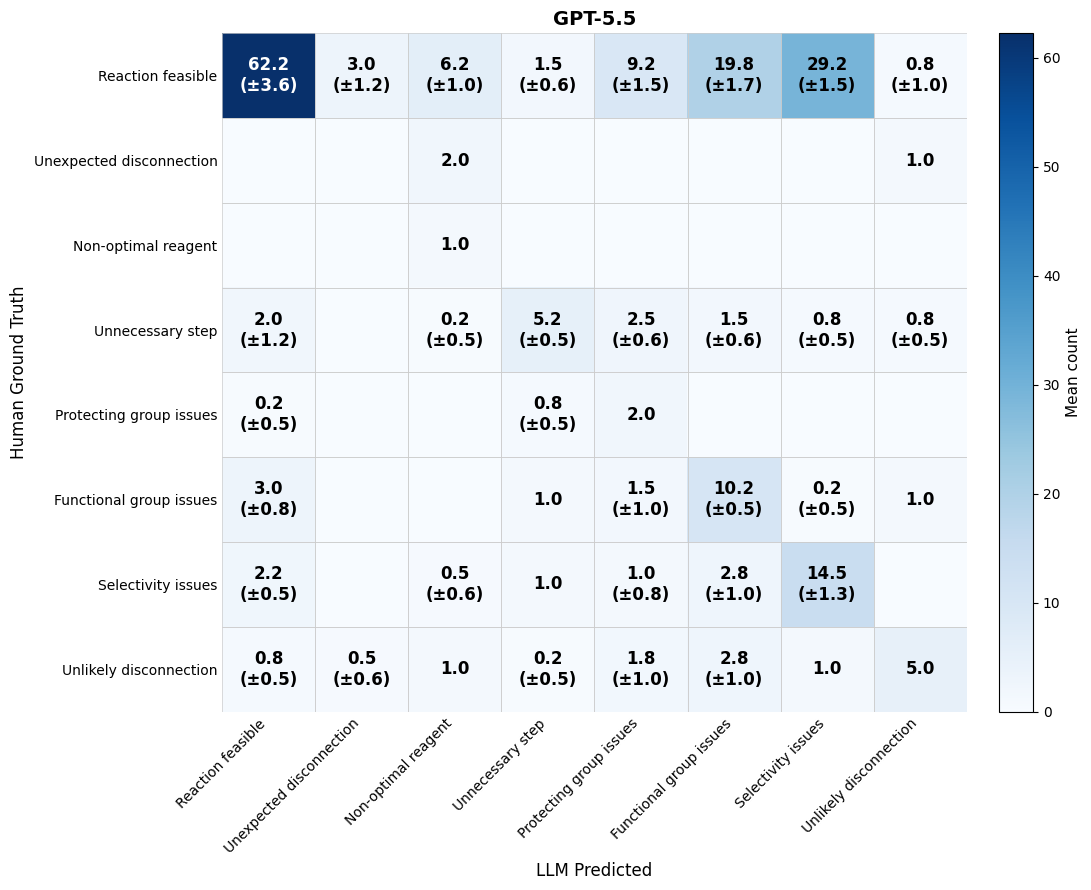

Saved results/averaged_cm_categories_GPT-5.5_Reaction.png


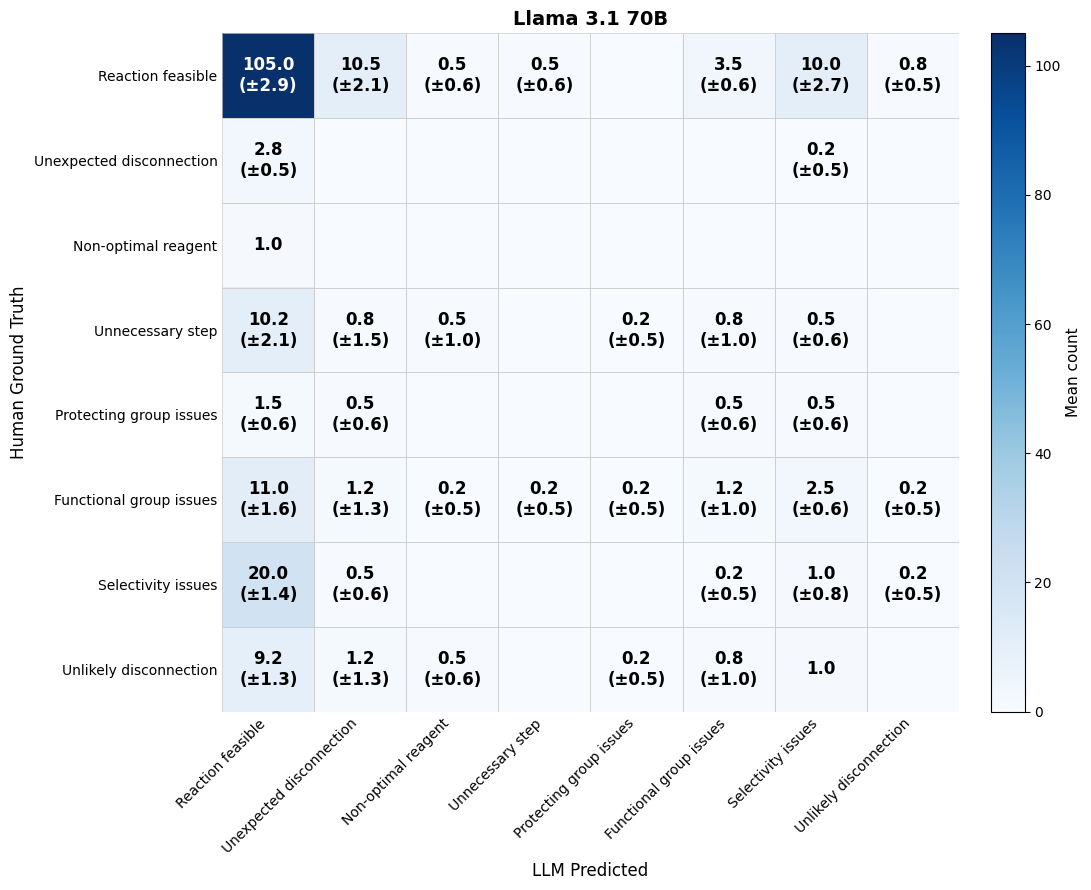

Saved results/averaged_cm_categories_Llama_3.1_70B_Reaction.png


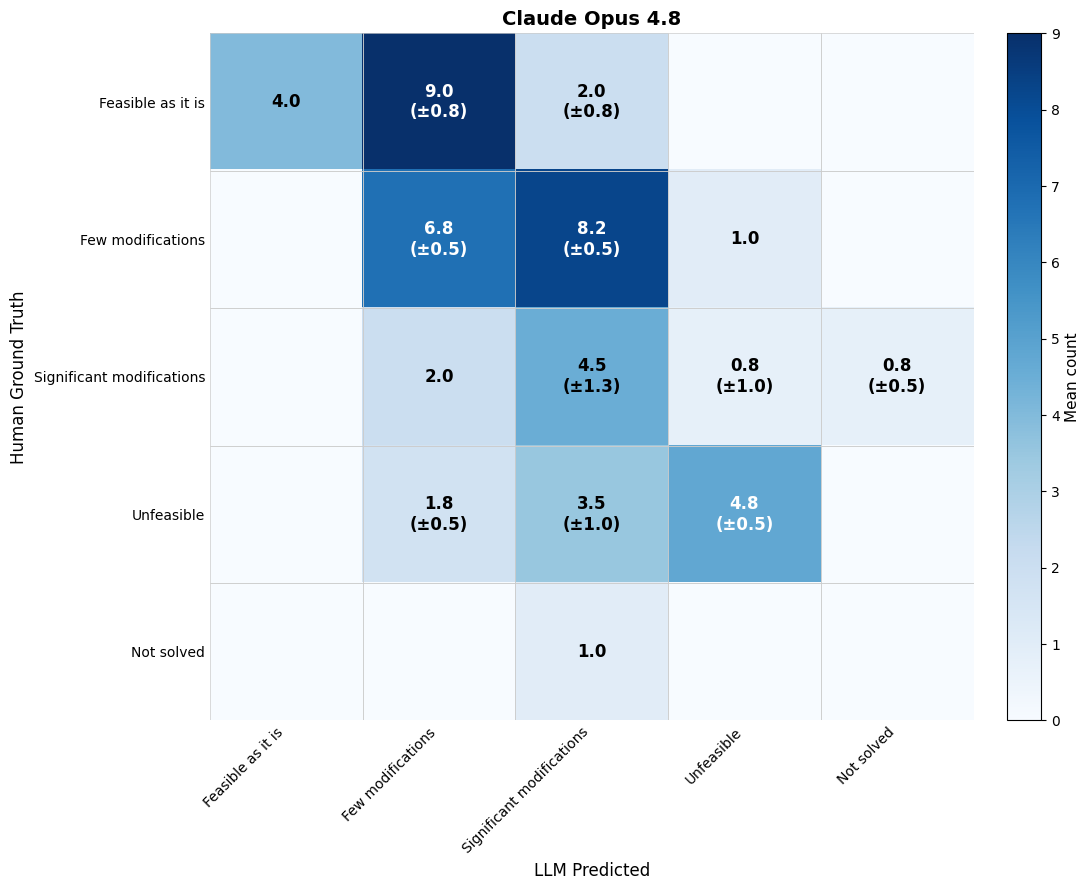

Saved results/averaged_cm_categories_Claude_Opus_4.8_Route.png


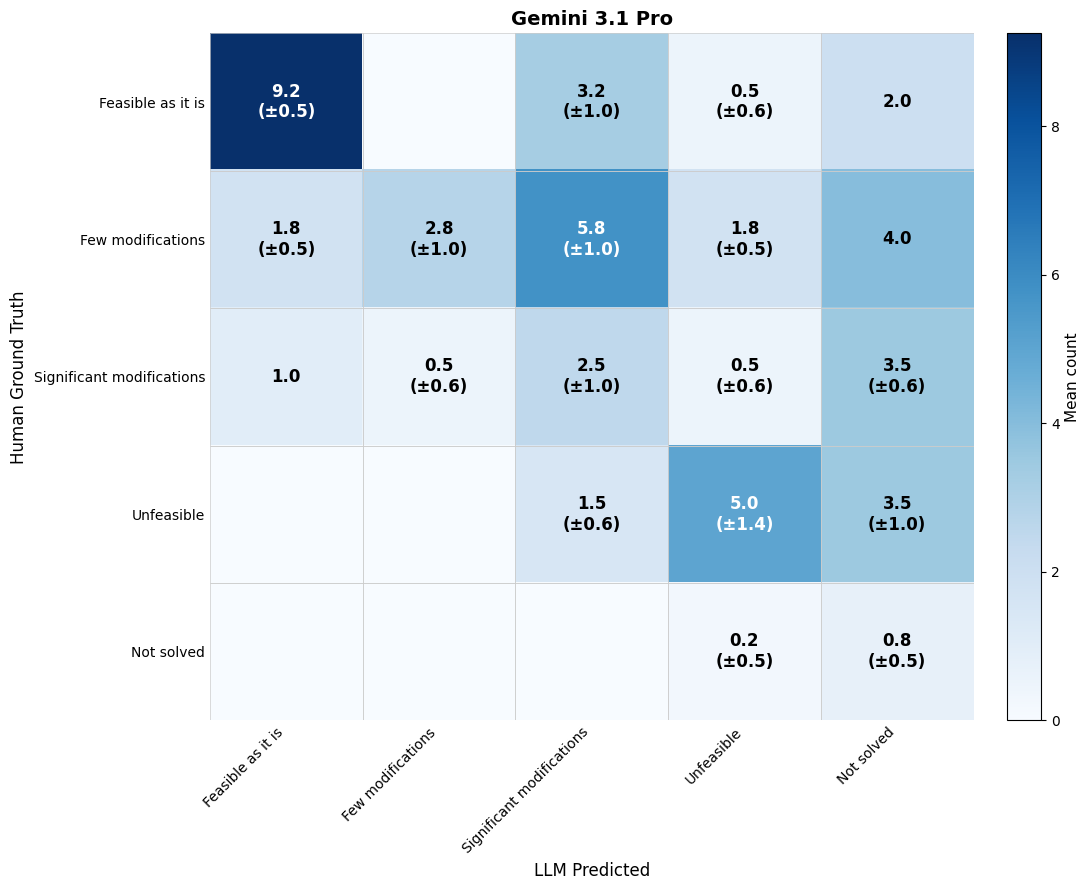

Saved results/averaged_cm_categories_Gemini_3.1_Pro_Route.png


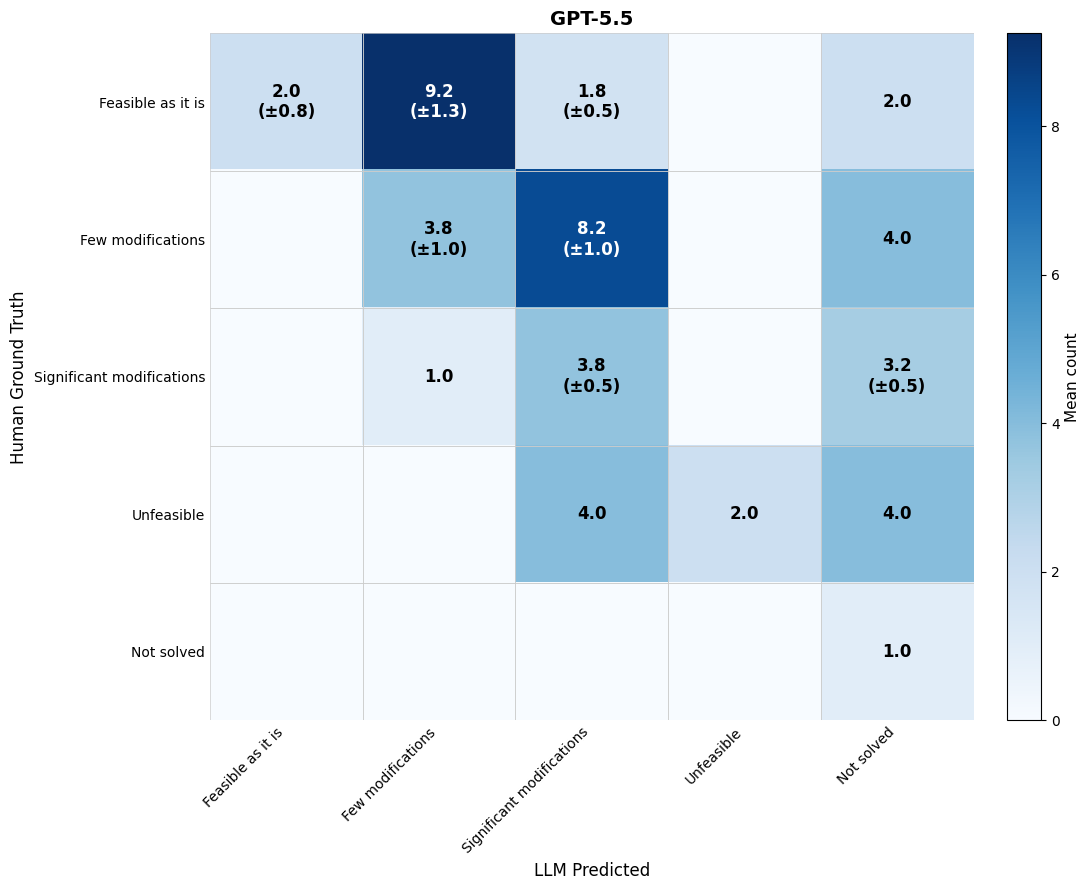

Saved results/averaged_cm_categories_GPT-5.5_Route.png


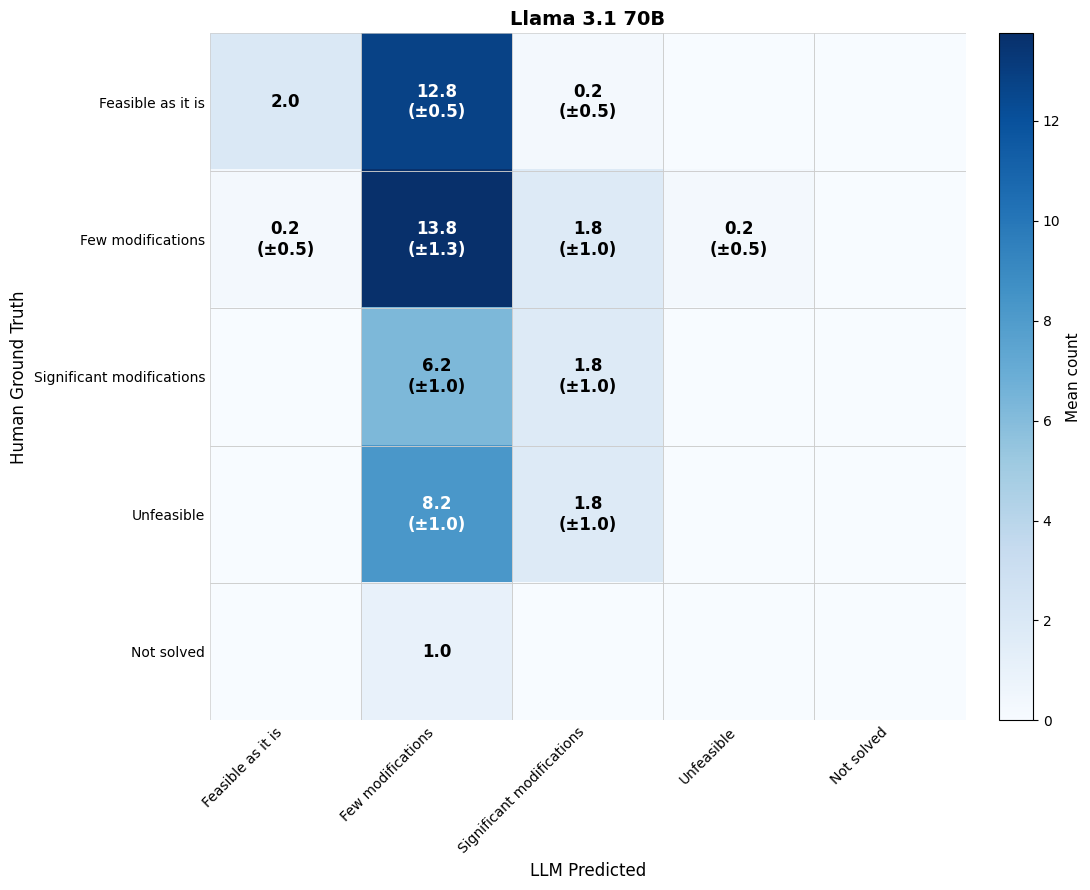

Saved results/averaged_cm_categories_Llama_3.1_70B_Route.png


In [6]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix as sk_cm
os.makedirs("results", exist_ok=True)

# Reuse human_labels, llm_df, ga, LLM_IDENTIFIERS, repeats from Option A cell
CSV = "expert_feedback_combined_new_llms.csv"
df_full = pd.read_csv(CSV)
human_mask = ~df_full["source_file"].isin(LLM_IDENTIFIERS)

def _avg_cat_cm(hash_col, cat_col, text_col, analysis_type):
    """Build and plot averaged category confusion matrix for reactions or routes."""
    h_df = df_full[human_mask & df_full[cat_col].notna() & df_full[hash_col].notna()].copy()
    l_df = df_full[~human_mask & df_full[cat_col].notna() & df_full[hash_col].notna()].copy()
    if "repeat" in l_df.columns:
        l_df = l_df[l_df["repeat"].notna()].copy()

    mappings  = CategoryMappings.get_mappings(hash_col)
    hierarchy = mappings["hierarchy"]
    aliases   = mappings["aliases"]
    ga_local  = GroupConsensusAnalyzer(hash_col)

    # Human ground truth labels (category, not binary)
    h_labels = {}
    for hsh, grp in h_df.groupby(hash_col):
        res = ga_local.get_group_consensus(grp, "source_file", cat_col, text_col)
        if res["dominant_category"] not in ("No feedback", "Unknown"):
            h_labels[hsh] = res["dominant_category"]

    # All valid categories, sorted
    all_cats = sorted(
        {c for c in list(h_labels.values()) + l_df[cat_col].dropna().tolist()
         if c in hierarchy},
        key=lambda x: (-hierarchy.get(x, -1), x)
    )
    alias_labels = [aliases.get(c, c) for c in all_cats]
    n_cats = len(all_cats)
    cat_to_idx = {c: i for i, c in enumerate(all_cats)}

    reps = sorted(l_df["repeat"].dropna().unique().astype(int)) if "repeat" in l_df.columns else [0]

    for llm in LLM_IDENTIFIERS:
        cm_stack = []
        for r in reps:
            sub = l_df[(l_df["source_file"] == llm) & (l_df["repeat"] == r)]
            y_true_cats, y_pred_cats = [], []
            for hsh, grp in sub.groupby(hash_col):
                if hsh not in h_labels or h_labels[hsh] not in cat_to_idx:
                    continue
                res = ga_local.get_group_consensus(grp, "source_file", cat_col, text_col)
                l_cat = res["dominant_category"]
                if l_cat not in cat_to_idx:
                    continue
                y_true_cats.append(cat_to_idx[h_labels[hsh]])
                y_pred_cats.append(cat_to_idx[l_cat])
            if len(y_true_cats) < 2:
                continue
            cm = sk_cm(y_true_cats, y_pred_cats, labels=list(range(n_cats)))
            cm_stack.append(cm)

        if not cm_stack:
            print(f"No data for {llm} ({analysis_type})")
            continue

        cm_arr  = np.array(cm_stack, dtype=float)
        cm_mean = cm_arr.mean(axis=0)
        cm_sd   = cm_arr.std(axis=0, ddof=1) if len(cm_arr) > 1 else np.zeros_like(cm_mean)

        fig, ax = plt.subplots(figsize=(11, 9))
        #im = ax.imshow(cm_mean, cmap="Blues", aspect="equal",
        #               vmin=0, vmax=max(cm_mean.max(), 1))
        im = ax.imshow(cm_mean, cmap='Blues', aspect='auto')
        ax.set_xticks(range(n_cats))
        ax.set_xticklabels(alias_labels, rotation=45, ha="right", fontsize=10)
        ax.set_yticks(range(n_cats))
        ax.set_yticklabels(alias_labels, fontsize=10)
        ax.set_xlabel("LLM Predicted", fontsize=12)
        ax.set_ylabel("Human Ground Truth", fontsize=12)
        ax.set_title(f"{llm}",
                     fontsize=14, fontweight="bold")
        cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        cbar.set_label("Mean count", fontsize=11, rotation=90)
        thresh = cm_mean.max() / 2.0 if cm_mean.max() > 0 else 1
        for i in range(n_cats):
            for j in range(n_cats):
                m, s = cm_mean[i, j], cm_sd[i, j]
                if m < 0.05:
                    continue
                txt = f"{m:.1f}\n(±{s:.1f})" if s > 0.05 else f"{m:.1f}"
                ax.text(j, i, txt, ha="center", va="center", fontsize=12,
                        fontweight="bold",
                        color="white" if m > thresh else "black")
        for i in range(n_cats):
            for j in range(n_cats):
                ax.add_patch(plt.Rectangle((j - 0.5, i - 0.5), 1, 1,
                             fill=False, edgecolor="#cccccc", linewidth=0.5))
        ax.spines[:].set_visible(False)
        ax.tick_params(length=0)
        plt.tight_layout()
        safe = llm.replace(" ", "_")
        out = f"results/averaged_cm_categories_{safe}_{analysis_type}.png"
        plt.savefig(out, dpi=200, bbox_inches="tight")
        plt.show()
        print(f"Saved {out}")

# Reactions
_avg_cat_cm(
    hash_col="reaction_hash",
    cat_col="local_feedback",
    text_col="local_feedback_text",
    analysis_type="Reaction",
)

# Routes
_avg_cat_cm(
    hash_col="root_molecule_hash",
    cat_col="general_feedback",
    text_col="general_feedback_text",
    analysis_type="Route",
)
